<a href="https://colab.research.google.com/github/guilhermeandrd/CRUD_Internacao/blob/main/trabalho_tbd_analise_de_sentimento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


link do relatorio (ir atualizando conforme projeto anda e depois só revisar):


https://www.overleaf.com/9585645646wvrcmtjhykkb#925050



dataset que será usado:

https://www.kaggle.com/datasets/fredericods/ptbr-sentiment-analysis-datasets/data?select=b2w.csv

# Importações e configurações

In [13]:
import pandas as pd
import os
from google.colab import userdata
import kagglehub
from IPython.display import display

In [14]:
from matplotlib import pyplot as plt

In [15]:
import seaborn as sns

# 1. Conjunto de dados


1.1. Baixe o dataset, carregue as amostras de treino e teste em um dataframe.

In [16]:
# Download latest version
path = kagglehub.dataset_download("fredericods/ptbr-sentiment-analysis-datasets")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ptbr-sentiment-analysis-datasets' dataset.
Path to dataset files: /kaggle/input/ptbr-sentiment-analysis-datasets


In [17]:
path_real = path+"/b2w.csv"
data = pd.read_csv(path_real)
data.head()

,original_index,review_text,review_text_processed,review_text_tokenized,polarity,rating,kfold_polarity,kfold_rating
0,11955,Bem macio e felpudo...recomendo. Preço imbatí...,bem macio e felpudo...recomendo. preco imbati...,"['bem', 'macio', 'felpudo', 'recomendo', 'prec...",1.0,4,1,1
1,35478,Produto excepcional! recomendo!!! inovador e ...,produto excepcional! recomendo!!! inovador e ...,"['produto', 'excepcional', 'recomendo', 'inova...",1.0,5,1,1
2,122760,recebi o produto antes do prazo mas veio com d...,recebi o produto antes do prazo mas veio com d...,"['recebi', 'produto', 'antes', 'do', 'prazo', ...",0.0,1,1,1
3,17114,Bom custo beneficio. Adequado para pessoas que...,bom custo beneficio. adequado para pessoas que...,"['bom', 'custo', 'beneficio', 'adequado', 'par...",1.0,5,1,1
4,19112,Além de higiênico tem o tamanho ideal. Só falt...,alem de higienico tem o tamanho ideal. so falt...,"['alem', 'de', 'higienico', 'tem', 'tamanho', ...",NaN,3,-1,1


# 1.2 Separação dos Dados Em de Teste e Treino

In [18]:
import numpy as np

# para treinamento em relação às classes, vamos dividi-las em positivo e negativo
# negativo indo de 1 a 2
# positivo indo de 3 a 5
# além disso, precisamos ter o mesmo tanto de cada classe de polaridade

# inicializa a coluna 'sentiment_class' com np.nan para lidar com ratings fora do esperado ou NaN
data['sentiment_class'] = np.nan

# usando df.loc para atribuição condicional
data.loc[data['rating'] <= 2, 'sentiment_class'] = 'negativo'
data.loc[(data['rating'] >= 3) & (data['rating'] <= 5), 'sentiment_class'] = 'positivo'

print(data['sentiment_class'].value_counts())

sentiment_class
positivo    96615
negativo    35758
Name: count, dtype: int64


/tmp/ipykernel_28034/3264854471.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'negativo' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  data.loc[data['rating'] <= 2, 'sentiment_class'] = 'negativo'


In [19]:
from sklearn.model_selection import train_test_split

X = data.drop('sentiment_class', axis=1)
y = data['sentiment_class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Tamanho total do dataset: {len(data)}")
print(f"Tamanho do conjunto de treino: {len(X_train)}")
print(f"Tamanho do conjunto de teste: {len(X_test)}")

print("\nDistribuição de classes no dataset original:")
print(y.value_counts(normalize=True))

print("\nDistribuição de classes no conjunto de treino:")
print(y_train.value_counts(normalize=True))

print("\nDistribuição de classes no conjunto de teste:")
print(y_test.value_counts(normalize=True))

Tamanho total do dataset: 132373
Tamanho do conjunto de treino: 105898
Tamanho do conjunto de teste: 26475

Distribuição de classes no dataset original:
sentiment_class
positivo    0.729869
negativo    0.270131
Name: proportion, dtype: float64

Distribuição de classes no conjunto de treino:
sentiment_class
positivo    0.729872
negativo    0.270128
Name: proportion, dtype: float64

Distribuição de classes no conjunto de teste:
sentiment_class
positivo    0.729858
negativo    0.270142
Name: proportion, dtype: float64


# 2. Análise Exploratória

In [20]:
print("Total de instâncias: ")
data.shape

Total de instâncias: 


(132373, 9)

In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132373 entries, 0 to 132372
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   original_index         132373 non-null  int64  
 1   review_text            132373 non-null  object 
 2   review_text_processed  132373 non-null  object 
 3   review_text_tokenized  132373 non-null  object 
 4   polarity               116058 non-null  float64
 5   rating                 132373 non-null  int64  
 6   kfold_polarity         132373 non-null  int64  
 7   kfold_rating           132373 non-null  int64  
 8   sentiment_class        132373 non-null  object 
dtypes: float64(1), int64(4), object(4)
memory usage: 9.1+ MB


In [22]:
print("Distribuição entre classes: ")

# consideraremos as classes o rating e a polarity
data['polarity'].value_counts()

Distribuição entre classes: 


,count
polarity,
1.0,80300
0.0,35758


In [23]:
data['rating'].value_counts()


,count
rating,
5,47955
4,32345
1,27369
3,16315
2,8389


In [24]:
print("Presença de classes desbalanceadas: ")

# mostrar o gráfico de rating e polarity


Presença de classes desbalanceadas: 


/tmp/ipykernel_28034/3030356146.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=data, palette='viridis')


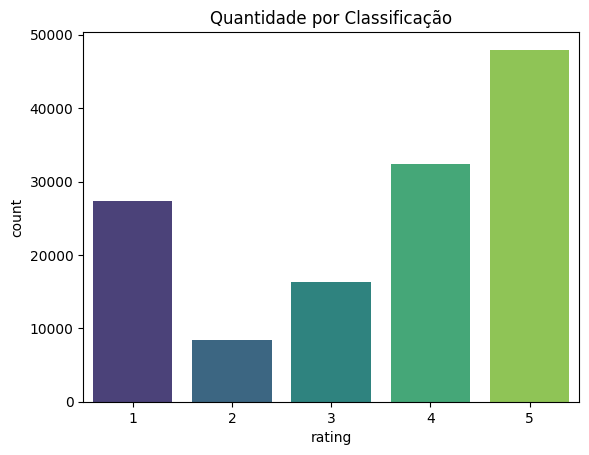

In [25]:
sns.countplot(x='rating', data=data, palette='viridis')

plt.title('Quantidade por Classificação')
plt.show()

/tmp/ipykernel_28034/758180312.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment_class', data=data, palette="viridis")


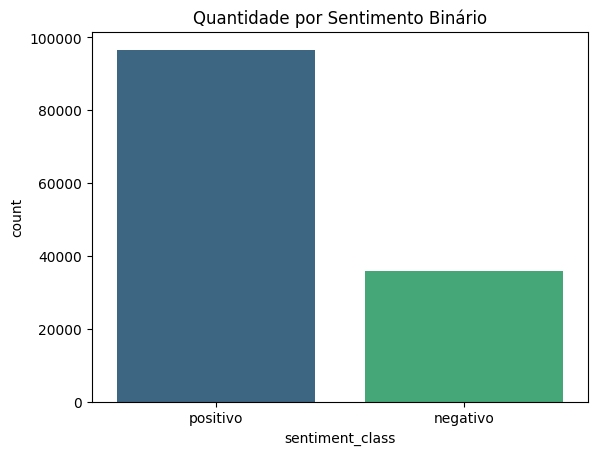

In [26]:
sns.countplot(x='sentiment_class', data=data, palette="viridis")
plt.title("Quantidade por Sentimento Binário")
plt.show()

/tmp/ipykernel_28034/2183556204.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='polarity', data=data, palette="viridis")


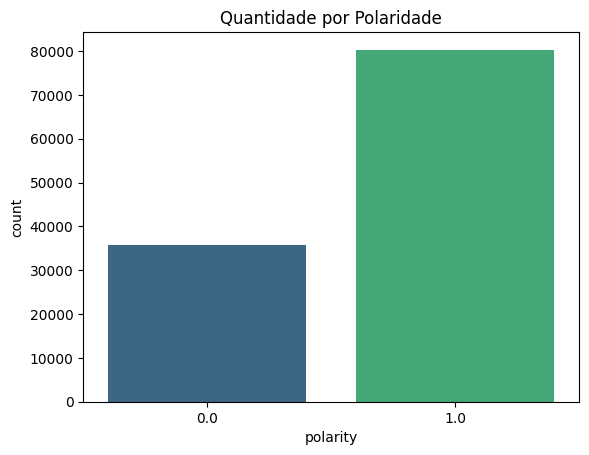

In [27]:
sns.countplot(x='polarity', data=data, palette="viridis")
plt.title('Quantidade por Polaridade')
plt.show()

In [28]:
print("Tamanho médio dos textos: ")

tamanho = 0
for text in data['review_text']:
  tamanho += len(text.split())

tam_rt = data['review_text'].count()

print(tamanho/tam_rt)

Tamanho médio dos textos: 
23.877837625497648


In [29]:
# montar um dicionario de frequencia e printar as 20 primeiras
from collections import Counter
import ast

print("Palavras mais frequentes: ")

token_reviews = data['review_text_tokenized'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

todas_palavras = [palavra for sublista in token_reviews for palavra in sublista]

frequencia_palavras = Counter(todas_palavras)

mais_comuns = frequencia_palavras.most_common(20)
for palavra, frequencia in mais_comuns:
    print(f"{palavra}: {frequencia}")




Palavras mais frequentes: 
de: 90117
produto: 74739
nao: 73223
que: 65774
muito: 53053
do: 43736
com: 43301
para: 34479
um: 34221
bom: 26428
da: 25945
recomendo: 25220
entrega: 24143
no: 23889
em: 23610
na: 19698
mas: 19537
uma: 19225
mais: 18980
bem: 17359


In [30]:
# montar vocabulario

def converte_para_lista(txt):
  if isinstance(txt, str):
    return ast.literal_eval(txt)
  return txt

tokens_reais = data['review_text_tokenized'].apply(converte_para_lista)

vocabulario = set(todas_palavras)

print(f"vocabulário total: {len(vocabulario)} palavras")


vocabulário total: 51761 palavras


In [31]:
print("Textos duplicados ou vazios: ")

vazios = data['review_text'].isnull().sum()

duplicados = data['review_text'].duplicated().sum()

print(f"Textos vazios: {vazios}")
print(f"Textos duplicados: {duplicados}")

Textos duplicados ou vazios: 
Textos vazios: 0
Textos duplicados: 2581


In [32]:
print("Valores ausentes: ")

# verificar todos os textos e ver quais são "vazios"
n_valores_ausentes = 0

for texto in data['review_text_processed']:
  if texto == "." or texto == " ":
    n_valores_ausentes+=1
    n_valores_ausentes+=1
  elif len(texto.split()) < 2:
    print(texto)
  # else:
    # print(len(texto.split()))
# print(n_valores_ausentes)

# não existem valores ausentes, mas sim alguns textos que são apenas ruídos
# como sequência de pontos, "kkk", "xxx", etc.

Valores ausentes: 
................................................................................
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!1
.................................................................................................................................................................................................................................................
perfeito..........................................
gostei................................................................................
....................................................................
bom....................................................................................................................................
ruiruiiiiiuiiiiiiiiiiiiiiiiiiiiiruiiiiiiiiiiiiiiii8iiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiii
excelente!.....................................................
divertido.........................................................................
.............

In [33]:
print("Exemplos reais de cada classe: ")

print("Exemplos da classe positivo: ")

# imprimir 20 exemplos
pd.set_option('display.max_colwidth', None)
data[data['sentiment_class'] == 'positivo']['review_text'].head(20)

Exemplos reais de cada classe: 
Exemplos da classe positivo: 


,review_text
0,Bem macio e felpudo...recomendo. Preço imbatível e entrega rápida. Compraria outro quando precisar
1,Produto excepcional! recomendo!!! inovador e gostoso de ler!!
3,Bom custo beneficio. Adequado para pessoas que fazem um uso casual do aparelho . A máquina fotográfica é excelente . A tela fornece imagens ótimas . Os recursos do aparelho são fáceis de manejar.
4,"Além de higiênico tem o tamanho ideal. Só faltou colher e garfo de sobremesa. Talvez se viesse com mais peças, eu gostaria mais."
5,"ótmo produto atendeu as expectativas, a entrega ocorreu antes do previsto. muito bom"
6,"GOSTEI MUITO DO PRODUTO! TEM ÓTIMA QUALIDADE, E FACILITA MUITO A APLICAÇÃO DO GEL."
7,"Adorei, entrega no prazo e produto conforme eu esperava, recomendadíssimo."
8,Já é o segundo processador deste modelo que compro (o primeiro foi para minha mãe) e só tenho elogios. É muito forte e facilita bastante os processos.
9,"Nao recebi!!! endereço para entrega : rua augusto hog, 186 casa 02 jardim presidente dutra guarulhos sp cep 07172200 favor enviar!!!"
11,"Adorei o smartphone, excelente acabamento, veloz e muito intuitivo"


In [34]:
print("Exemplos da classe negativo: ")

# imprimir 20 exemplos
pd.set_option('display.max_colwidth', None)
data[data['sentiment_class'] == 'negativo']['review_text'].head(20)

Exemplos da classe negativo: 


,review_text
2,recebi o produto antes do prazo mas veio com defeito na trava ou seja não da para usar e até agora a Americanas não resolveu e preciso muito deste produto
10,"Não compra este produto, pois o mesmo veio com os botões travados e ao tentar ligar o mesmo nem ligou. Péssima qualidade."
12,"Tive azar, pois o produto não ligou. Tive que entregar para o fornecedor."
13,Uma enganação! Esperei quase um mês e cancelaram o pedido. E o produto continua disponível. Nem entraram em contato. Palhaçada!!! #carrodemola
25,Cancelei 10 minutos depois que efetuei a compra e me mandaram mesmo assim
28,Na estação do som tudo correto mas a estalar os autuofalante não sai som.
32,"Balcão bonito. Entrega no prazo. Material frágil. Veio faltando parafusos para fixação do tampo, assim como faltou a proteção (cor preta) atrás do tampo, que aparece na imagem. Montagem fácil, mas o manual de instruções poderia ser mais completo. Não recomendo pela falta dos parafusos e da proteção."
40,Estou decepcionada com o serviço oferecido pela americanas. Venceu o prazo de entrega e não recebi o produto.
41,"Bom dia não posso fazer avaliação, pois o produto foi incompatível para rodar no XBOX 360, não havia notado no rodapé da capa que tem que teria que ter o XBOX GOLD, tentei realizar a troca na loja física de Presidente Prudente mais não foi possível."
43,"No primeiro uso já encheu de bolinhas nas mangas, o atrito do moletom cria varias bolinhas."


In [35]:
print("")

#3.1 Tratamento dos Dados

In [36]:
# remover dados nulos
# nan
# ausentes

In [37]:
data.isnull().sum()

,0
original_index,0
review_text,0
review_text_processed,0
review_text_tokenized,0
polarity,16315
rating,0
kfold_polarity,0
kfold_rating,0
sentiment_class,0


In [38]:
# reaproveitei a limpeza que tu tinha feito e so coloquei aqui (ass gui)

data_sem_duplicata = data.drop_duplicates(subset=['review_text'])
data_limpo = data_sem_duplicata.dropna()

print(f"Tamanho apos limpeza: {len(data_limpo)}")

Tamanho apos limpeza: 113647


In [39]:
data_limpo.isnull().sum()

,0
original_index,0
review_text,0
review_text_processed,0
review_text_tokenized,0
polarity,0
rating,0
kfold_polarity,0
kfold_rating,0
sentiment_class,0


In [40]:
# acho que aqui já podemos equilibrar as classes também,
# pegando a mesma quantidade de cada

# 3.2 Pré procesamento

In [41]:
# o dataframe já tem uma coluna com os dados tokenizados, mas optamos por tratar eles do zero
# depois iremos fazer uma pequena comparação com a coluna dos dados tokenizados nativa

### 3.2.1. Limpeza de nulos e duplicados

In [42]:
print(f'tamanho inicial: {len(data)}')

data = data.dropna(subset=['review_text'])
data = data.drop_duplicates(subset=['review_text'], keep='first')

print(f'tamanho final: {len(data)}')

tamanho inicial: 132373
tamanho final: 129792


### 3.2.2. Lowercasing e remoção de pontuação

In [43]:
import re

#lowecasing:
data['review_text'] = data['review_text'].str.lower()

#removendo pontuação e garantindo separação de palavras
def limpeza(texto):
  # Substitui qualquer caractere que não seja letra (incluindo acentuadas), número ou espaço por um espaço
  texto = re.sub(r'[^a-zA-Z0-9\s\u00C0-\u017F]', ' ', texto, flags=re.UNICODE)
  # Remove espaços extras que podem resultar da substituição de múltiplas pontuações
  return re.sub(r'\s+', ' ', texto).strip()

data['review_text'] = data['review_text'].apply(limpeza)

print(f'Exemplo apos lowecasing e limpeza: {data['review_text'].head()}')

Exemplo apos lowecasing e limpeza: 0                                                                                                 bem macio e felpudo recomendo preço imbatível e entrega rápida compraria outro quando precisar
1                                                                                                                                        produto excepcional recomendo inovador e gostoso de ler
2                                     recebi o produto antes do prazo mas veio com defeito na trava ou seja não da para usar e até agora a americanas não resolveu e preciso muito deste produto
3    bom custo beneficio adequado para pessoas que fazem um uso casual do aparelho a máquina fotográfica é excelente a tela fornece imagens ótimas os recursos do aparelho são fáceis de manejar
4                                                                   além de higiênico tem o tamanho ideal só faltou colher e garfo de sobremesa talvez se viesse com mais peças eu gostaria mais


### #3.2.3. Tokenização

In [44]:
import nltk
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')

data['tokens'] = data['review_text'].apply(word_tokenize)
print('resultado: ')
print(data[['review_text', 'tokens']].head())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


resultado: 
                                                                                                                                                                                   review_text  \
0                                                                                               bem macio e felpudo recomendo preço imbatível e entrega rápida compraria outro quando precisar   
1                                                                                                                                      produto excepcional recomendo inovador e gostoso de ler   
2                                   recebi o produto antes do prazo mas veio com defeito na trava ou seja não da para usar e até agora a americanas não resolveu e preciso muito deste produto   
3  bom custo beneficio adequado para pessoas que fazem um uso casual do aparelho a máquina fotográfica é excelente a tela fornece imagens ótimas os recursos do aparelho são fáceis de manejar   
4                 

### #3.2.4. stopwords

In [45]:
from nltk.corpus import stopwords

nltk.download('stopwords')

palavras_irre = set(stopwords.words('portuguese'))

def filtra(lista):
  return [palavra for palavra in lista if palavra not in palavras_irre]

data['tokens'] = data['tokens'].apply(filtra)
print('resultado: ')
print(data[['review_text', 'tokens']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


resultado: 
                                                                                                                                                                                   review_text  \
0                                                                                               bem macio e felpudo recomendo preço imbatível e entrega rápida compraria outro quando precisar   
1                                                                                                                                      produto excepcional recomendo inovador e gostoso de ler   
2                                   recebi o produto antes do prazo mas veio com defeito na trava ou seja não da para usar e até agora a americanas não resolveu e preciso muito deste produto   
3  bom custo beneficio adequado para pessoas que fazem um uso casual do aparelho a máquina fotográfica é excelente a tela fornece imagens ótimas os recursos do aparelho são fáceis de manejar   
4                 

### #3.2.5. Lematização

In [46]:
from nltk import RSLPStemmer

nltk.download('rslp')

lema = RSLPStemmer()

def aplica(lista):
  return [lema.stem(palavra) for palavra in lista]

data['tokens_lem'] = data['tokens'].apply(aplica)
print('resultado: ')
print(data[['review_text', 'tokens_lem']].head())

[nltk_data] Downloading package rslp to /root/nltk_data...
[nltk_data]   Package rslp is already up-to-date!


resultado: 
                                                                                                                                                                                   review_text  \
0                                                                                               bem macio e felpudo recomendo preço imbatível e entrega rápida compraria outro quando precisar   
1                                                                                                                                      produto excepcional recomendo inovador e gostoso de ler   
2                                   recebi o produto antes do prazo mas veio com defeito na trava ou seja não da para usar e até agora a americanas não resolveu e preciso muito deste produto   
3  bom custo beneficio adequado para pessoas que fazem um uso casual do aparelho a máquina fotográfica é excelente a tela fornece imagens ótimas os recursos do aparelho são fáceis de manejar   
4                 

#?. Visualização

###?.1. Histograma #

count    129792.000000
mean         14.010324
std          13.410219
min           0.000000
25%           7.000000
50%          10.000000
75%          16.000000
max         618.000000
Name: tamanho_textos, dtype: float64


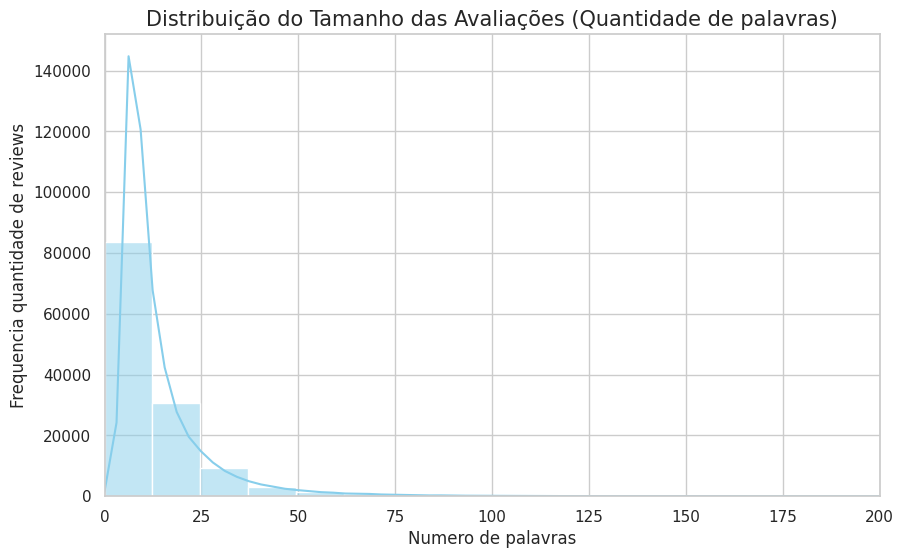

In [47]:
data['tamanho_textos'] = data['tokens'].apply(len)
print(data['tamanho_textos'].describe())

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.histplot(data['tamanho_textos'], bins=50, kde=True, color='skyblue')

plt.title('Distribuição do Tamanho das Avaliações (Quantidade de palavras)', fontsize=15)
plt.xlabel('Numero de palavras', fontsize='12')
plt.ylabel('Frequencia quantidade de reviews', fontsize=12)

plt.xlim(0, 200)

plt.show()

###?.2. nuvem de palavras #

<function matplotlib.pyplot.show(close=None, block=None)>

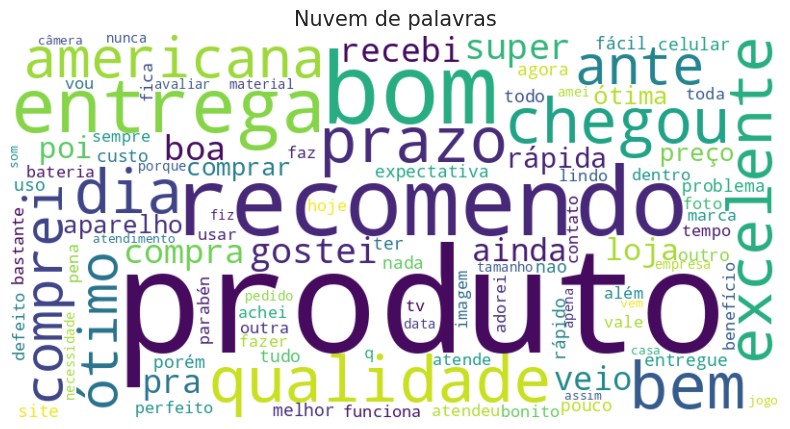

In [48]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

texto_para_nuvem = ' '.join([' '.join(lista) for lista in data['tokens']])

nuvem = WordCloud(width=800,
                  height=400,
                  background_color='white',
                  colormap='viridis',
                  max_words=100,
                  collocations=False).generate(texto_para_nuvem)

plt.figure(figsize=(10, 5))
plt.imshow(nuvem, interpolation='bilinear')
plt.axis('off')
plt.title('Nuvem de palavras', fontsize=15)
plt.show


### Tabela Resumo da Análise

In [49]:
print('Contagem de classes de sentimento:')
print(data['sentiment_class'].value_counts())

print('\nValores nulos por coluna após o pré-processamento:')
print(data.isnull().sum())

print('\nEstatísticas descritivas do tamanho dos textos (em caracteres):')
print(data['tamanho_textos'].describe())

print('\nTamanho do vocabulário após o pré-processamento:')
vocab_processed = set(' '.join([' '.join(tokens) for tokens in data['tokens_lem']]).split())
print(len(vocab_processed))

Contagem de classes de sentimento:
sentiment_class
positivo    95364
negativo    34428
Name: count, dtype: int64

Valores nulos por coluna após o pré-processamento:
original_index               0
review_text                  0
review_text_processed        0
review_text_tokenized        0
polarity                 16145
rating                       0
kfold_polarity               0
kfold_rating                 0
sentiment_class              0
tokens                       0
tokens_lem                   0
tamanho_textos               0
dtype: int64

Estatísticas descritivas do tamanho dos textos (em caracteres):
count    129792.000000
mean         14.010324
std          13.410219
min           0.000000
25%           7.000000
50%          10.000000
75%          16.000000
max         618.000000
Name: tamanho_textos, dtype: float64

Tamanho do vocabulário após o pré-processamento:
29162


# 4.1 TF-IDF

In [50]:
# transformando todos as lista de tokens em uma lista só


all_corpus_tokens = [token for sublist in data['tokens'] for token in sublist]



In [51]:
# reaproveitamento de funções já feitas

def preprocess(text: str) -> list:
    # text: texto bruto de entrada
    # retorno: lista de tokens de text
    text = text.lower()
    text = text.replace(',','')
    text = text.replace('.','')
    text = text.replace('\n','')

    tokens = text.split(' ')
    tokens = [token for token in tokens if token]
    return tokens

def build_vocab(tokens: list) -> dict:
    # tokens: lista de palavras do corpus (todos os documentos)
    # retorno: {'words': list, 'word2idx': dict}, onde words é indexa
    # todas as palavras do corpus e word2idx indexa um dicionário que
    # mapeia cada palavra a um valor numérico inteiro

    unique_words = sorted(list(set(tokens)))
    vocab = {'words': unique_words, 'word2idx': {}}

    for i, word in enumerate(unique_words):
      vocab['word2idx'][word] = i

    return vocab

def compute_tf(tokens: list, vocab: dict) -> list:
    # tokens: lista de palavras de um documento
    # vocab: {'words': list, 'word2idx': dict} construido por build_vocab
    # retorno: vetor de frequências (lista)
    tf_vector = [0] * len(vocab['words'])
    for token in tokens:
        if token in vocab['word2idx']:
            tf_vector[vocab['word2idx'][token]] += 1

    return tf_vector

def compute_tfidf(docs_tokens: list, vocab: dict) -> list:
    # docs_tokens: lista de documentos, cada um sendo lista de tokens
    # vocab: {'words': list, 'word2idx': dict} construido por build_vocab
    # retorno: matriz tfidf (lista de listas)

    tfs = []
    for doc_tokens in docs_tokens:
        tfs.append(compute_tf(doc_tokens, vocab))

    num_docs = len(docs_tokens)
    idf_vector = [0] * len(vocab['words'])
    for i, word in enumerate(vocab['words']):
        doc_count = 0
        for doc_tokens in docs_tokens:
            if word in doc_tokens:
                doc_count += 1
        if doc_count > 0:
            idf_vector[i] = np.log(num_docs / doc_count)

    tfidf_matrix = []
    for tf_vec in tfs:
        tfidf_vec = [tf * idf for tf, idf in zip(tf_vec, idf_vector)]
        tfidf_matrix.append(tfidf_vec)

    return tfidf_matrix

def cosine_similarity(vec1: list, vec2: list) -> float:
    # vec1: vetor numérico 1
    # vec2: vetor numérico 2
    # retorno: valor numérico da similaridade

    n_vec1 = np.array(vec1)
    n_vec2 = np.array(vec2)

    norm_vec1 = np.linalg.norm(n_vec1)
    norm_vec2 = np.linalg.norm(n_vec2)

    # otimizacao para os calculos
    if norm_vec1 == 0 or norm_vec2 == 0:
        return 0.0

    cos_sim = np.dot(n_vec1, n_vec2) / (norm_vec1 * norm_vec2)
    return cos_sim

### 3.3 Funções de Pré-processamento Genéricas Baseadas em Implementações Anteriores

Com base nas funções de pré-processamento que você já utilizou (`limpeza`, `filtra`, `aplica`), criaremos versões genéricas que podem ser aplicadas consistentemente aos conjuntos de treino e teste. Isso garante a reutilização do código e a padronização do pré-processamento.

In [52]:
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk import RSLPStemmer

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('rslp', quiet=True)

palavras_irre_generica = set(stopwords.words('portuguese'))
lema_generica = RSLPStemmer()

def generic_clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9\s\u00C0-\u017F]', ' ', text, flags=re.UNICODE)
    return re.sub(r'\s+', ' ', text).strip()

def generic_tokenize_text(text):
    return word_tokenize(text)

def generic_remove_stopwords(tokens):
    return [palavra for palavra in tokens if palavra not in palavras_irre_generica]

def generic_lemmatize_tokens(tokens):
    return [lema_generica.stem(palavra) for palavra in tokens]

### 3.4 Aplicação das Funções Genéricas aos Dados de Treino e Teste

Agora, aplicaremos essas funções genéricas aos conjuntos `X_train` e `X_test`. Cada etapa criará uma nova coluna, preservando as colunas originais e permitindo a inspeção de cada fase do pré-processamento.

In [ ]:
# 1. Aplicação da limpeza de texto (lowercasing e remoção de pontuação)
X_train['review_text_cleaned'] = X_train['review_text'].apply(generic_clean_text)
X_test['review_text_cleaned'] = X_test['review_text'].apply(generic_clean_text)

print("Limpeza de texto aplicada a 'review_text_cleaned'.")
print("\nExemplo de X_train após limpeza:")
display(X_train[['review_text', 'review_text_cleaned']].head())

In [ ]:
# 2. Aplicação da tokenização
X_train['tokens_processed'] = X_train['review_text_cleaned'].apply(generic_tokenize_text)
X_test['tokens_processed'] = X_test['review_text_cleaned'].apply(generic_tokenize_text)

print("Tokenização aplicada a 'tokens_processed'.")
print("\nExemplo de X_train após tokenização:")
display(X_train[['review_text_cleaned', 'tokens_processed']].head())

In [ ]:
# 3. Aplicação da remoção de stopwords
X_train['tokens_no_stopwords'] = X_train['tokens_processed'].apply(generic_remove_stopwords)
X_test['tokens_no_stopwords'] = X_test['tokens_processed'].apply(generic_remove_stopwords)

print("Remoção de stopwords aplicada a 'tokens_no_stopwords'.")
print("\nExemplo de X_train após remoção de stopwords:")
display(X_train[['tokens_processed', 'tokens_no_stopwords']].head())

In [ ]:
# 4. Aplicação da lematização
X_train['tokens_lemmatized'] = X_train['tokens_no_stopwords'].apply(generic_lemmatize_tokens)
X_test['tokens_lemmatized'] = X_test['tokens_no_stopwords'].apply(generic_lemmatize_tokens)

print("Lematização aplicada a 'tokens_lemmatized'.")
print("\nExemplo de X_train após lematização:")
display(X_train[['tokens_no_stopwords', 'tokens_lemmatized']].head())

In [ ]:
print("Pré-processamento completo para X_train e X_test usando funções genéricas.")
print("\nColunas de X_train atualizadas:", X_train.columns.tolist())
print("\nColunas de X_test atualizadas:", X_test.columns.tolist())

# 4.2 Word2Vec


# 4.3 FastText




# 5. Treinamento do Modelo

## 5.1 Entrada Vetorial

# 5. Texto curto vs Texto Longo

#